Cleaning The Dataset

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv(r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train.csv")

In [79]:
#Fix Inconsistent Text

#Merge 'Check-out' into 'Check-Out'
df['Reservation_Status'] = df['Reservation_Status'].replace({'Check-out': 'Check-Out'})

#Fix capitalization in Ethnicity
df['Ethnicity'] = df['Ethnicity'].replace({'caucasian': 'Caucasian'})

In [80]:
#Convert Dates to Datetime Objects
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [81]:
#Lead Time
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

In [82]:
#Length of Stay
df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

In [83]:
# Keep dataset
df_clean = df.copy()

# Remove invalid stays only
df_clean = df_clean[df_clean['Length_of_Stay'] > 0]

# Optional: cap extreme lead times
df_clean['Lead_Time'] = df_clean['Lead_Time'].clip(lower=-30)



In [84]:
df.isnull().sum()

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
Lead_Time                 0
Length_of_Stay            0
dtype: int64

In [85]:
df.to_csv(r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train-cleaned.csv", index=False)

Univariate Analysis

In [86]:
df = pd.read_csv(r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train-cleaned.csv")


In [88]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

C:\Users\venuk\AppData\Local\Temp\ipykernel_10436\2320507388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='Reservation_Status', data=df, palette='viridis')


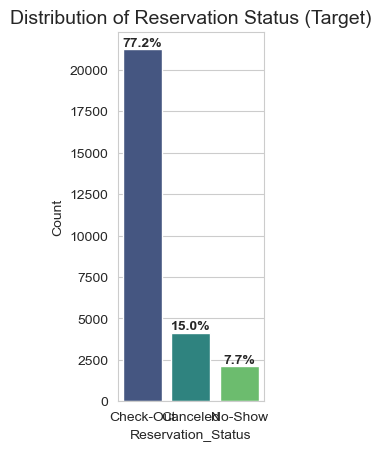

In [89]:
#Target Variable Distribution (Reservation Status)

plt.subplot(1, 3, 1)
status_counts = df['Reservation_Status'].value_counts(normalize=True) * 100
ax1 = sns.countplot(x='Reservation_Status', data=df, palette='viridis')
plt.title('Distribution of Reservation Status (Target)', fontsize=14)
plt.ylabel('Count')

for p in ax1.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / len(df))
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax1.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

Text(0, 0.5, 'Frequency')

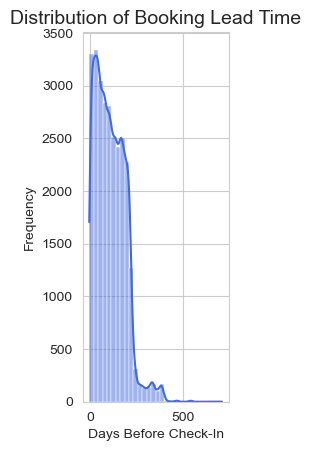

In [91]:
#Lead Time Distribution (Histogram)

plt.subplot(1, 3, 2)
sns.histplot(df['Lead_Time'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Booking Lead Time', fontsize=14)
plt.xlabel('Days Before Check-In')
plt.ylabel('Frequency')

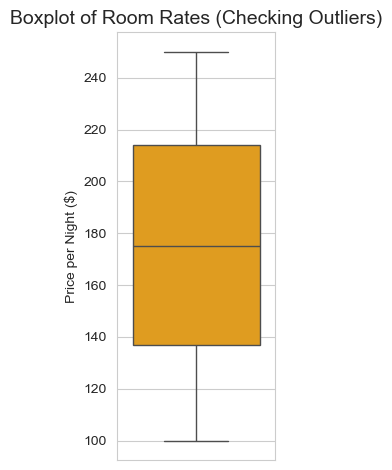

In [92]:
#Room Rate Distribution (Boxplot for Outliers)

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Room_Rate'], color='orange')
plt.title('Boxplot of Room Rates (Checking Outliers)', fontsize=14)
plt.ylabel('Price per Night ($)')

plt.tight_layout()
plt.show()

In [93]:
df.isnull().sum()

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
Lead_Time                 0
Length_of_Stay            0
dtype: int64

In [96]:
df.to_csv(r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train_cleaned.csv", index=False)